B.8. Implement  KNN,  Naïve  Bayes,  and  SVM  classifiers  using  Python-based  ML  tools  for 
comparison of their performance on the review sentiment classification dataset.  
 

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import List
import re
from collections import Counter
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Convert TF-IDF dictionaries to vectors
from sklearn.feature_extraction import DictVectorizer

#this is just to get data for SVM
from sklearn.datasets import make_blobs

import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/rito/.cache/kagglehub/datasets/abhi8923shriv/sentiment-analysis-dataset/versions/9


$\textbf{KNN}$

Kth nearest neighbors(KNN) does not require any training In a way the dataset itself is the model. we are going to use the dataset itself and the nearest neighbors the predict which cluster out data belong to by calculating the euclidean distance from out point to the nearest points.   

formula for euclidean distance on n dimensions are given below: 

The Euclidean distance in n-dimensions is the straight-line distance between two points, generalized from the Pythagorean theorem: it's the square root of the sum of the squared differences between their corresponding coordinates across all n dimensions. For points $(P_{1}(x_{1},x_{2},\dots ,x_{n})) and (P_{2}(y_{1},y_{2},\dots ,y_{n})·)$, the formula is

$d(p_1,p_2)=\sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$

Formula

Points: $(P_{1}=(x_{1},x_{2},\dots ,x_{n})) and (P_{2}=(y_{1},y_{2},\dots ,y_{n}))$.

Distance: $(d(P_{1},P_{2})=\sqrt{(x_{1}-y_{1})^{2}+(x_{2}-y_{2})^{2}+\dots +(x_{n}-y_{n})^{2}})$

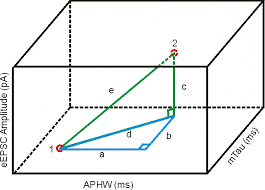

In [26]:
path = path + "/train.csv"
data = pd.read_csv(path, encoding='latin1')
df = pd.DataFrame(data)

In [27]:
sentiment_map = {
    'negative': 0,
    'neutral': 1,
    'positive': 1
}

df['sentiment_label'] = df['sentiment'].map(sentiment_map)

In [28]:
time_map = {
    'morning': [1,0,0],
    'noon': [0,1,0],
    'night': [0,0,1]
}

df['time_label'] = df['Time of Tweet'].map(time_map)

In [29]:
class TfIdf:
    def __init__(self):
        self.vocab = set()
        self.df_count = {}
        self.idf = {}
        self.N = 0
    
    def tokenize(self, text):
        if not isinstance(text, str):
            return []   # ignore NaN or non-string values
        cleaned_text = re.sub(r"[^\w\s]", "", text)
        return cleaned_text.lower().split()

    def build_vocab(self, df, column='message'):
        """Build vocabulary from all documents"""
        self.vocab = set()
        
        for i in range(len(df)):
            tokens = self.tokenize(df.loc[i, column])
            self.vocab = self.vocab.union(tokens)
        
        return self.vocab
    
    def compute_tf(self, tokens):
        """Compute term frequency for a document"""
        if not tokens:
            return {}
        tf = Counter(tokens)
        total = len(tokens)
        return {word: count / total for word, count in tf.items()}

    def compute_df_count(self, df, column='message'):
        """Count document frequency for each word"""
        self.df_count = dict.fromkeys(self.vocab, 0)
        self.N = len(df)

        for i in range(len(df)):
            text = df.loc[i, column]
            tokens = set(self.tokenize(text))  # IMPORTANT: set() to count each word once per document
            for word in tokens:
                if word in self.df_count:
                    self.df_count[word] += 1
        
        return self.df_count
    
    def compute_idf(self):
        """Compute IDF values for all words in vocabulary"""
        self.idf = {}
        for word, df_val in self.df_count.items():
            self.idf[word] = np.log((self.N + 1) / (df_val + 1)) + 1
        
        return self.idf
    
    def compute_tfidf(self, tf):
        """Compute TF-IDF scores given TF values"""
        return {word: tf[word] * self.idf.get(word, 0) for word in tf}

    def compute_text_tfidf(self, text):
        """Compute TF-IDF for a single text document"""
        tokens = self.tokenize(text)
        tf = self.compute_tf(tokens)
        return self.compute_tfidf(tf)
    
    def fit(self, df, column='message'):
        """Fit the TF-IDF model on a dataframe"""
        self.build_vocab(df, column)
        self.compute_df_count(df, column)
        self.compute_idf()
        return self
    
    def transform(self, df, column='message'):
        """Transform documents to TF-IDF vectors"""
        tfidf_scores = []
        for i in range(len(df)):
            text = df.loc[i, column]
            tfidf = self.compute_text_tfidf(text)
            tfidf_scores.append(tfidf)
        return tfidf_scores
    
    def fit_transform(self, df, column='message'):
        """Fit and transform in one step"""
        self.fit(df, column)
        return self.transform(df, column)

In [14]:
# def tokenize(text):
#     if not isinstance(text, str):
#         return []   # ignore NaN or non-string values
#     cleaned_text = re.sub(r"[^\w\s]", "", text)
#     return cleaned_text.lower().split()


In [15]:
# vocal_class = set()

# for i in range(1, len(df['sentiment'])):
#     d1 = tokenize(df.loc[i,'text'])
#     d2 = tokenize(df.loc[i-1,'text'])

#     vocal_class = vocal_class.union(d1,d2)

In [16]:
# def compute_tf(tokens):
#     if not tokens:
#         return {}
#     tf = Counter(tokens)
#     total = len(tokens)
#     return {word: count / total for word, count in tf.items()}

In [17]:
# df_count = dict.fromkeys(vocal_class, 0)

# for text in df['text']:
#     tokens = set(tokenize(text))  # IMPORTANT: set()
#     for word in tokens:
#         df_count[word] += 1

In [18]:
# N = len(df['text'])

# idf = {}
# for word, df_val in df_count.items():
#     idf[word] = np.log((N + 1) / (df_val + 1)) + 1


In [19]:
# def compute_tfidf(tf, idf):
#     return {word: tf[word] * idf.get(word, 0) for word in tf}

In [20]:
# tf_idf = []

# def compute_text_tfidf(text):
#     tokens = tokenize(text)
#     tf = compute_tf(tokens)
#     return compute_tfidf(tf, idf)


In [21]:
# df['text_tf_idf'] = df['text'].apply(compute_text_tfidf)

In [30]:
# Initialize the TF-IDF model
tfidf_model = TfIdf()

# Option 1: Get dictionaries first (like your original code)
df['text_tf_idf'] = tfidf_model.fit_transform(df, column='text')

# Then vectorize (exactly like your original code)
vectorizer = DictVectorizer(sparse=False)
X_all = vectorizer.fit_transform(df['text_tf_idf'].tolist())
y_all = df['sentiment_label'].values


In [ ]:
# vectorizer = DictVectorizer(sparse=False)
# X_all = vectorizer.fit_transform(df['text_tf_idf'].tolist())
# y_all = df['sentiment_label'].values

In [31]:
# Use only a sample of your data
sample_size = 5000  # Adjust based on your PC's RAM
df_sample = df.sample(n=sample_size, random_state=42)

# Then convert to vectors
vectorizer = DictVectorizer(sparse=False)
X_sample = vectorizer.fit_transform(df_sample['text_tf_idf'].tolist())
y_sample = df_sample['sentiment_label'].values

# Now split - this should work
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

In [32]:
def euclidean_dist(p,q):
    return np.sqrt(np.sum((np.array(p) - np.array(q))**2))

In [33]:
# 4. Modify your KNN class to work with the data format
class KNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X_train, y_train):
        """Store training data"""
        self.X_train = X_train
        self.y_train = y_train
    
    def predict(self, X_test):
        """Predict labels for test data"""
        predictions = []
        
        for test_point in X_test:
            # Calculate distances to all training points
            distances = []
            for i, train_point in enumerate(self.X_train):
                distance = euclidean_dist(train_point, test_point)
                distances.append((distance, self.y_train[i]))
            
            # Sort by distance and get k nearest neighbors
            distances.sort(key=lambda x: x[0])
            k_nearest = distances[:self.k]
            
            # Get the most common label
            k_labels = [label for _, label in k_nearest]
            prediction = Counter(k_labels).most_common(1)[0][0]
            predictions.append(prediction)
        
        return np.array(predictions)


In [34]:
k = KNN(k=5)
k.fit(X_train,y_train)
y_prid = k.predict(X_test)

In [35]:
acc_knn = accuracy_score(y_test, y_prid)
precision_knn = precision_score(y_test, y_prid, average='weighted')
recall_knn = recall_score(y_test, y_prid, average='weighted')
f1_knn = f1_score(y_test, y_prid, average='weighted')

print(f"Accuracy: {acc_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_prid, target_names=['negative','positive']))

Accuracy: 0.7080
Precision: 0.6622
Recall: 0.7080
F1-Score: 0.6634

Classification Report:
              precision    recall  f1-score   support

    negative       0.46      0.19      0.27       283
    positive       0.74      0.91      0.82       717

    accuracy                           0.71      1000
   macro avg       0.60      0.55      0.55      1000
weighted avg       0.66      0.71      0.66      1000



$\textbf{Confusion Matrix}$

Confusion matrix is a simple table used to measure how well a classification model is performing. It compares the predictions made by the model with the actual results and shows where the model was right or wrong. This helps you understand where the model is making mistakes so you can improve it. It breaks down the predictions into four categories

True Positive (TP): The model correctly predicted a positive outcome i.e the actual outcome was positive.

True Negative (TN): The model correctly predicted a negative outcome i.e the actual outcome was negative.

False Positive (FP): The model incorrectly predicted a positive outcome i.e the actual outcome was negative. It is also known as a Type I error.

False Negative (FN): The model incorrectly predicted a negative outcome i.e the actual outcome was positive. It is also known as a Type II error.

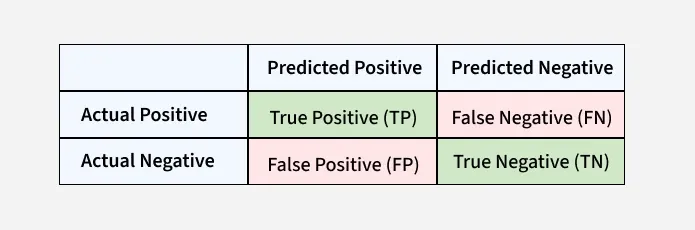

1. $\textbf{Accuracy:}$ Accuracy shows how many predictions the model got right out of all the predictions

$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$


2. $\textbf{Precision:}$ Precision focus on the quality of the model’s positive predictions. 

$Precision = \frac{TP}{TP + TN}$

3. $\textbf{Recall:}$ Recall measures how how good the model is at predicting positives.

$Recall = \frac{TP}{TP + FN}$

4. $\textbf{F1-Score:}$ F1-score combines precision and recall into a single metric to balance their trade-off. It provides a better sense of a model’s overall performance particularly for imbalanced datasets

F1-Score= $\frac{2 \times Precision \times Recall}{Precision + Recall}$

In [36]:
class CM:
    def accuracy(self, test, prid):
        TP = TN = 0
        for i in range(len(test)):
            if test[i] == 1 and prid[i] == 1:
                TP += 1
            elif test[i] == 0 and prid[i] == 0:
                TN += 1
        return (TP + TN) / len(test)

    def precision(self, test, prid):
        TP = FP = 0
        for i in range(len(test)):
            if test[i] == 1 and prid[i] == 1:
                TP += 1
            elif test[i] == 0 and prid[i] == 1:
                FP += 1
        return TP / (TP + FP) if (TP + FP) != 0 else 0

    def recall(self, test, prid):
        TP = FN = 0
        for i in range(len(test)):
            if test[i] == 1 and prid[i] == 1:
                TP += 1
            elif test[i] == 1 and prid[i] == 0:
                FN += 1
        return TP / (TP + FN) if (TP + FN) != 0 else 0

    def f1_score(self, test, prid):
        p = self.precision(test, prid)
        r = self.recall(test, prid)
        return (2 * p * r) / (p + r) if (p + r) != 0 else 0


In [37]:
cm = CM()
print(f"Accuracy: {cm.accuracy(y_test,y_prid):.4f}")
print(f"Precision: {cm.precision(y_test,y_prid):.4f}")
print(f"Recall: {cm.recall(y_test,y_prid):.4f}")
print(f"F1-Score: {cm.f1_score(y_test,y_prid):.4f}")
print("\nClassification Report:")

Accuracy: 0.7080
Precision: 0.7412
Recall: 0.9107
F1-Score: 0.8173

Classification Report:
